# Лабораторна робота 2 (варіант №1)

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Variant #1 polygon (matching the provided shape proportions)
POLYGON = np.array(
    [
        [0.0, 25.0],
        [25.0, 0.0],
        [75.0, 0.0],
        [100.0, 25.0],
        [50.0, 50.0],
    ]
)

N_MAIN = 150
N_TEST = 30
X_MIN, X_MAX = 0.0, 100.0
Y_MIN, Y_MAX = 0.0, 50.0
SEED = 42

OUT_DIR = Path("figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
def cross(o, a, b):
    return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])


def convex_hull(points):
    pts = np.asarray(points)
    n = len(pts)
    if n < 3:
        return np.arange(n)

    idx_ymin = np.argmin(pts[:, 1])
    y_min = pts[idx_ymin, 1]
    cand = np.where(pts[:, 1] == y_min)[0]
    start = cand[np.argmin(pts[cand, 0])]

    angles = np.arctan2(pts[:, 1] - pts[start, 1], pts[:, 0] - pts[start, 0])
    dists = np.sum((pts - pts[start]) ** 2, axis=1)
    order = np.lexsort((-dists, angles))
    order = order[order != start]
    order = np.concatenate([[start], order])

    stack = [order[0], order[1]]
    for i in range(2, n):
        k = order[i]
        while len(stack) >= 2 and cross(pts[stack[-2]], pts[stack[-1]], pts[k]) <= 0:
            stack.pop()
        stack.append(k)

    return np.array(stack)


def scale_to_square(pts, x_c, y_c, k, scale_x):
    out = pts.copy()
    if scale_x:
        out[:, 0] = (out[:, 0] - x_c) / k + x_c
    else:
        out[:, 1] = (out[:, 1] - y_c) / k + y_c
    return out


def line_coefficients(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    a = y1 - y2
    b = x2 - x1
    c = x1 * y2 - x2 * y1
    return np.array([a, b, c], dtype=float)


def signed_distance(line_abc, point):
    a, b, c = line_abc
    x0, y0 = point
    return (a * x0 + b * y0 + c) / math.sqrt(a * a + b * b)


def polygon_edge_lines(poly):
    lines = []
    for i in range(len(poly)):
        p1 = poly[i]
        p2 = poly[(i + 1) % len(poly)]
        lines.append(line_coefficients(p1, p2))
    return np.array(lines)


def inside_sign(lines, ref_point):
    vals = np.array([signed_distance(line, ref_point) for line in lines])
    nonzero = vals[np.abs(vals) > 1e-12]
    if len(nonzero) == 0:
        return 1.0
    return np.sign(nonzero[0])


def classify_point_by_rho(lines, point, in_sign, eps=1e-10):
    rho = np.array([signed_distance(line, point) for line in lines])
    on_boundary = np.any(np.abs(rho) <= eps)
    signs = np.sign(rho[np.abs(rho) > eps])
    if len(signs) == 0:
        return "boundary", rho
    if np.all(signs == in_sign):
        if on_boundary:
            return "boundary", rho
        return "inside", rho
    return "outside", rho


def generate_points_in_polygon(lines, in_sign, n_points, rng):
    accepted = []
    while len(accepted) < n_points:
        candidate = np.array([
            rng.uniform(X_MIN, X_MAX),
            rng.uniform(Y_MIN, Y_MAX),
        ])
        status, _ = classify_point_by_rho(lines, candidate, in_sign)
        if status in {"inside", "boundary"}:
            accepted.append(candidate)
    return np.array(accepted)


def farthest_pair(points):
    best_d = -1.0
    pair = (0, 1)
    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            d = np.linalg.norm(points[i] - points[j])
            if d > best_d:
                best_d = d
                pair = (i, j)
    return pair, best_d


def rotate_points(points, theta):
    r = np.array([[math.cos(theta), math.sin(theta)], [-math.sin(theta), math.cos(theta)]])
    return points @ r.T


def rotate_back_points(points, theta):
    r_inv = np.array([[math.cos(theta), -math.sin(theta)], [math.sin(theta), math.cos(theta)]])
    return points @ r_inv.T

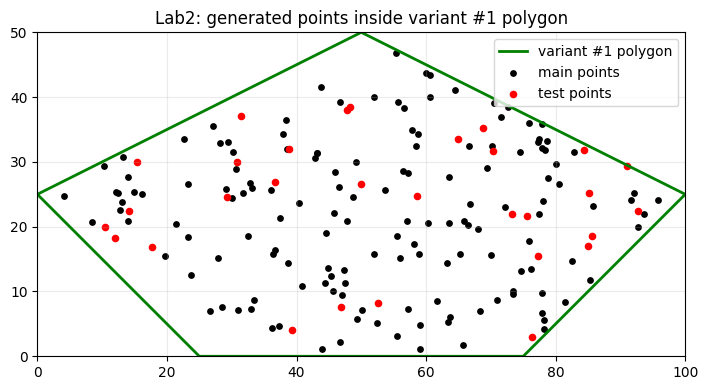

Edge lines (ax + by + c = 0):
L1: 25.000000*x + 25.000000*y + -625.000000 = 0
L2: 0.000000*x + 50.000000*y + 0.000000 = 0
L3: -25.000000*x + 25.000000*y + 1875.000000 = 0
L4: -25.000000*x + -50.000000*y + 3750.000000 = 0
L5: 25.000000*x + -50.000000*y + 1250.000000 = 0
Inside sign for reference point (np.float64(50.0), np.float64(20.0)): +1


In [3]:
# 1) Build line equations for polygon edges.
rng = np.random.default_rng(SEED)
lines = polygon_edge_lines(POLYGON)

# 2) Fix sign corresponding to inside using known interior point.
ref_point = np.array([50.0, 20.0])
in_sign = inside_sign(lines, ref_point)

# 3) Generate valid points (membership checked during generation).
main_points = generate_points_in_polygon(lines, in_sign, N_MAIN, rng)
test_points = generate_points_in_polygon(lines, in_sign, N_TEST, rng)

# Preview generated points inside polygon
plt.figure(figsize=(8, 4))
poly_closed = np.vstack([POLYGON, POLYGON[0]])
plt.plot(poly_closed[:, 0], poly_closed[:, 1], "g-", linewidth=2, label="variant #1 polygon")
plt.scatter(main_points[:, 0], main_points[:, 1], s=15, c="black", label="main points")
plt.scatter(test_points[:, 0], test_points[:, 1], s=20, c="red", label="test points")
plt.xlim(X_MIN, X_MAX)
plt.ylim(Y_MIN, Y_MAX)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(alpha=0.25)
plt.legend(loc="upper right")
plt.title("Lab2: generated points inside variant #1 polygon")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig1_input_points.png", dpi=150)
plt.show()

print("Edge lines (ax + by + c = 0):")
for i, (a, b, c) in enumerate(lines, start=1):
    print(f"L{i}: {a:.6f}*x + {b:.6f}*y + {c:.6f} = 0")
print(f"Inside sign for reference point {tuple(ref_point)}: {in_sign:+.0f}")

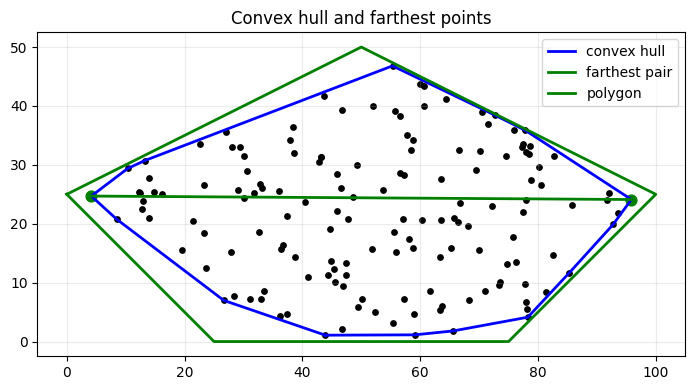

Farthest hull distance: 91.696366
Center: (-49.852109, -24.259379), k=2.002184, scale_x=True
Ellipse area stats: min=4.9898, max=3687.3162, mean=1518.5564


In [4]:
# convex hull and farthest pair.
hull_idx = convex_hull(main_points)
hull_points = main_points[hull_idx]
(i1, i2), far_d = farthest_pair(hull_points)
far_1 = hull_points[i1]
far_2 = hull_points[i2]

plt.figure(figsize=(8, 4))
hull_closed = np.vstack([hull_points, hull_points[0]])
plt.scatter(main_points[:, 0], main_points[:, 1], s=15, c="black")
plt.plot(hull_closed[:, 0], hull_closed[:, 1], "b-", linewidth=2, label="convex hull")
plt.plot([far_1[0], far_2[0]], [far_1[1], far_2[1]], "g-", linewidth=2, label="farthest pair")
plt.scatter([far_1[0], far_2[0]], [far_1[1], far_2[1]], c="green", s=60)
# Polygon boundary (variant #1)
poly_closed = np.vstack([POLYGON, POLYGON[0]])
plt.plot(poly_closed[:, 0], poly_closed[:, 1], "g-", linewidth=2, label="polygon")
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(alpha=0.25)
plt.legend()
plt.title("Convex hull and farthest points")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig2_convex_hull.png", dpi=150)
plt.show()

# Rotate so the farthest segment is horizontal.
dx, dy = far_2 - far_1
theta_rot = math.atan2(dy, dx)
main_rot = rotate_points(main_points, theta_rot)
test_rot = rotate_points(test_points, theta_rot)

# scale to square.
min_xy = main_rot.min(axis=0)
max_xy = main_rot.max(axis=0)
width = max_xy[0] - min_xy[0]
height = max_xy[1] - min_xy[1]
x_c = 0.5 * (max_xy[0] + min_xy[0])
y_c = 0.5 * (max_xy[1] + min_xy[1])
k = max(width, height) / min(width, height)
scale_x = width >= height

main_sq = scale_to_square(main_rot, x_c, y_c, k, scale_x)
test_sq = scale_to_square(test_rot, x_c, y_c, k, scale_x)

# nested circles and P for test points.
dist_main = np.linalg.norm(main_sq - np.array([x_c, y_c]), axis=1)
radii_ordered = np.sort(dist_main)
dist_test = np.linalg.norm(test_sq - np.array([x_c, y_c]), axis=1)

num_circles_per_point = np.sum(radii_ordered[:, np.newaxis] >= dist_test, axis=0)
max_circle_per_point = num_circles_per_point
n = len(radii_ordered)

p_test = np.zeros(len(test_sq))
statuses = []
for i in range(len(test_sq)):
    m = max_circle_per_point[i]
    if m == 0:
        p_test[i] = 0.0
        statuses.append("center (m=0)")
    elif m >= n:
        p_test[i] = 1.0
        statuses.append("edge/outside (m>=n)")
    else:
        p_test[i] = (m - 1) / (n + 1)
        statuses.append(f"inside (m={m}/{n})")

# ellipse areas.
ellipse_areas = []
for r in radii_ordered:
    if scale_x:
        a, b = k * r, r
    else:
        a, b = r, k * r
    ellipse_areas.append(math.pi * a * b)
ellipse_areas = np.array(ellipse_areas)

print(f"Farthest hull distance: {far_d:.6f}")
print(f"Center: ({x_c:.6f}, {y_c:.6f}), k={k:.6f}, scale_x={scale_x}")
print(
    f"Ellipse area stats: min={ellipse_areas.min():.4f}, "
    f"max={ellipse_areas.max():.4f}, mean={ellipse_areas.mean():.4f}"
)

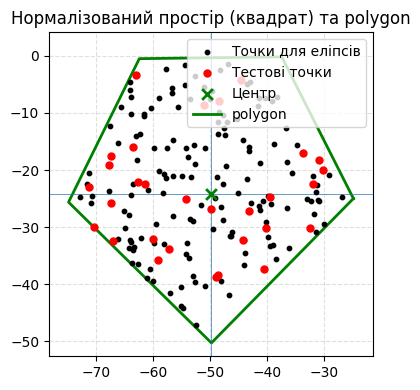

In [5]:
# 5) Нормалізована область (там де квадрат): main_sq / test_sq + polygon
poly_rot = rotate_points(POLYGON, theta_rot)
poly_sq = scale_to_square(poly_rot, x_c, y_c, k, scale_x)
poly_sq_closed = np.vstack([poly_sq, poly_sq[0]])

all_sq = np.vstack([main_sq, test_sq])
pad = 0.5
r_plot = (
    max(
        all_sq[:, 0].max() - x_c,
        x_c - all_sq[:, 0].min(),
        all_sq[:, 1].max() - y_c,
        y_c - all_sq[:, 1].min(),
    )
    + pad
)

plt.figure(figsize=(8, 4))
ax = plt.gca()
ax.scatter(main_sq[:, 0], main_sq[:, 1], color="black", s=10, label="Точки для еліпсів", zorder=3)
ax.scatter(test_sq[:, 0], test_sq[:, 1], color="red", marker="o", s=25, label="Тестові точки", zorder=4)
ax.scatter([x_c], [y_c], color="green", s=60, marker="x", linewidths=2, label="Центр", zorder=5)

# polygon boundary in normalized square
ax.plot(poly_sq_closed[:, 0], poly_sq_closed[:, 1], "g-", linewidth=2, label="polygon", zorder=2)

ax.set_xlim(x_c - r_plot -5 , x_c + r_plot + 5)
ax.set_ylim(y_c - r_plot - 5, y_c + r_plot + 5)
ax.set_aspect("equal", adjustable="box")
ax.axhline(y_c, linewidth=0.5)
ax.axvline(x_c, linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(loc="upper right")
ax.set_title("Нормалізований простір (квадрат) та polygon")
plt.tight_layout()
plt.show()

## 7. Зворотне масштабування та ймовірність належності

In [6]:
# 6) Перевірка тестових точок (як у lab1): у скількох колах лежить і ймовірність
print("Тестові точки (квадратні координати), кількість кіл")
for i in range(len(test_sq)):
    print(
        f"  Точка {i+1}: ({test_sq[i, 0]:.4f}, {test_sq[i, 1]:.4f}) — у {num_circles_per_point[i]} колах"
    )

# Ймовірність належності та статус
statuses_check = []
print("\nРезультат: ймовірність належності тестових точок")
print("№   m   P        Статус")
print("-" * 45)

for i in range(len(test_sq)):
    m = max_circle_per_point[i]
    if m == 0:
        statuses_check.append("внутрішня (центр)")
    elif m >= n:
        statuses_check.append("зовнішня (край)")
    else:
        statuses_check.append(f"m={m}/{n}")

    print(f"{i+1:<3} {m:<3} {p_test[i]:<8.4f} {statuses_check[i]}")

n_center = sum(1 for s in statuses_check if "центр" in s)
n_edge = sum(1 for s in statuses_check if "край" in s)
n_middle = len(statuses_check) - n_center - n_edge
print(
    f"\nСтатистика: {n_center} в центрі, {n_middle} у середині, {n_edge} на краю, "
    f"середня P = {p_test.mean():.4f}"
)

Тестові точки (квадратні координати), кількість кіл
  Точка 1: (-40.5123, -37.3339) — у 74 колах
  Точка 2: (-67.6738, -19.1586) — у 39 колах
  Точка 3: (-32.5297, -30.1393) — у 46 колах
  Точка 4: (-30.8721, -18.3219) — у 24 колах
  Точка 5: (-63.4661, -16.0398) — у 74 колах
  Точка 6: (-59.1860, -35.7078) — у 78 колах
  Точка 7: (-44.2218, -32.2909) — у 118 колах
  Точка 8: (-51.1524, -8.5220) — у 74 колах
  Точка 9: (-31.9538, -22.5021) — у 50 колах
  Точка 10: (-44.5473, -4.2526) — у 19 колах
  Точка 11: (-62.6088, -22.1699) — у 95 колах
  Точка 12: (-48.3695, -7.8326) — у 66 колах
  Точка 13: (-39.4620, -24.6955) — у 113 колах
  Точка 14: (-54.1644, -25.0377) — у 145 колах
  Точка 15: (-66.9843, -32.4164) — у 32 колах
  Точка 16: (-57.2680, -33.9232) — у 98 колах
  Точка 17: (-63.0468, -3.3916) — у 0 колах
  Точка 18: (-43.1774, -27.2095) — у 134 колах
  Точка 19: (-48.9327, -38.7381) — у 82 колах
  Точка 20: (-67.4263, -25.7820) — у 53 колах
  Точка 21: (-70.2869, -29.9352) — у 1

## 7. Зворотне масштабування та ймовірність належності


Rho table (first 10 rows):
idx x y rho1 rho2 rho3 rho4 rho5 class
 1   31.39   37.13 +30.7761 +37.1346 +57.0955 +19.8301 +3.1842 inside
 2   85.65   18.61 +56.0509 +18.6131 +5.6274 +12.1280 +44.0186 inside
 3   15.36   30.04 +14.4273 +30.0420 +63.4139 +33.3419 +2.3601 inside
 4   11.97   18.25 +3.6863 +18.2460 +57.4727 +45.4104 +11.3929 inside
 5   77.21   15.55 +47.9125 +15.5481 +9.4311 +18.6458 +42.9836 inside
 6   68.77   35.27 +55.8875 +35.2703 +29.3476 +4.7820 +21.5673 inside
 7   38.78   32.04 +32.4057 +32.0444 +48.2673 +21.0758 +11.0441 inside
 8   52.51    8.19 +25.2412 +8.1876 +21.6931 +36.2762 +38.5202 inside
 9   14.16   22.41 +8.1825 +22.4123 +58.8685 +40.7035 +8.6469 inside
10   39.26    4.00 +12.9116 +4.0025 +28.1041 +45.9457 +36.3372 inside


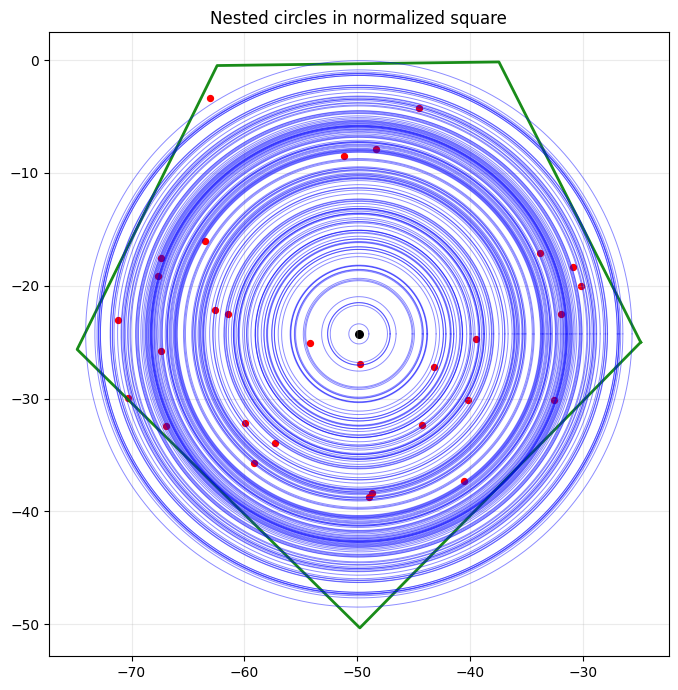

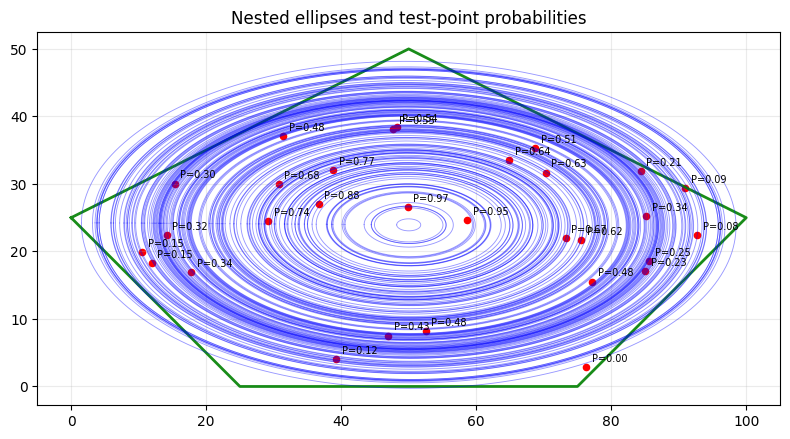

In [7]:
# Rho table for generated test points .
rho_table = []
membership_labels = []
for idx, p in enumerate(test_points):
    state, rho_vals = classify_point_by_rho(lines, p, in_sign)
    rho_table.append((idx + 1, p[0], p[1], *rho_vals.tolist(), state))
    membership_labels.append(state)

print("\nRho table (first 10 rows):")
print("idx x y rho1 rho2 rho3 rho4 rho5 class")
for row in rho_table[:10]:
    idx, x, y, *rest = row
    *rho_vals, cls = rest
    rho_str = " ".join([f"{rv:+.4f}" for rv in rho_vals])
    print(f"{idx:>2} {x:>7.2f} {y:>7.2f} {rho_str} {cls}")

# nested circles
plt.figure(figsize=(7, 7))
ax = plt.gca()
theta = np.linspace(0, 2 * np.pi, 220)

# polygon boundary in normalized square coordinates
poly_rot = rotate_points(POLYGON, theta_rot)
poly_sq = scale_to_square(poly_rot, x_c, y_c, k, scale_x)
poly_sq_closed = np.vstack([poly_sq, poly_sq[0]])
ax.plot(poly_sq_closed[:, 0], poly_sq_closed[:, 1], "g-", linewidth=2, alpha=0.9)

for r in radii_ordered:
    ax.plot(x_c + r * np.cos(theta), y_c + r * np.sin(theta), "b-", linewidth=0.7, alpha=0.45)
ax.scatter(test_sq[:, 0], test_sq[:, 1], c="red", s=18)
ax.scatter([x_c], [y_c], c="black", s=30)
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.25)
ax.set_title("Nested circles in normalized square")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig5_nested_circles.png", dpi=150)
plt.show()

# nested ellipses and probabilities
plt.figure(figsize=(8, 5))
ax = plt.gca()
t = np.linspace(0, 2 * np.pi, 220)

# polygon boundary in original coordinates (same frame as ellipses_world)
poly_closed = np.vstack([POLYGON, POLYGON[0]])
ax.plot(poly_closed[:, 0], poly_closed[:, 1], "g-", linewidth=2, alpha=0.9)

if scale_x:
    a_mult, b_mult = k, 1.0
else:
    a_mult, b_mult = 1.0, k
for r in radii_ordered:
    ex = x_c + a_mult * r * np.cos(t)
    ey = y_c + b_mult * r * np.sin(t)
    ellipse = np.column_stack([ex, ey])
    ellipse_world = rotate_back_points(ellipse, theta_rot)
    ax.plot(ellipse_world[:, 0], ellipse_world[:, 1], "b-", linewidth=0.65, alpha=0.4)

tests_world = rotate_back_points(test_rot, theta_rot)
ax.scatter(tests_world[:, 0], tests_world[:, 1], c="red", s=20)
for i in range(len(tests_world)):
    ax.annotate(f"P={p_test[i]:.2f}", (tests_world[i, 0], tests_world[i, 1]), xytext=(4, 4), textcoords="offset points", fontsize=7)
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.25)
ax.set_title("Nested ellipses and test-point probabilities")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig6_nested_ellipses.png", dpi=150)
plt.show()